# __N_BEATS MODEL: Predicción de la tendencia__

In [12]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

import pandas as pd
from datetime import datetime

#Gestionamos API
API_KEY = "PKCB2FGQTEQAIQXV5CXL6RJU4D" 
SECRET_KEY = "8gsG7rUpBvUaxAzw7HPw6EEypH42UpkR4VRYHaNJoYYU"

client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

# Definimos los datos que queremos descargar, su fecha de inicio y su fecha de fin
symbols = ["QQQ"]

start = datetime(2020,1,1)
end = datetime(2026,1,1)

# Descargamos los datos de ALPACA
request = StockBarsRequest(
    symbol_or_symbols=symbols,
    timeframe=TimeFrame(5, TimeFrameUnit.Minute),
    start=start,
    end=end
)

bars = client.get_stock_bars(request)

# Convertimos las columnas a dataset
df = bars.df
df = df.reset_index()
df.tail()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
282752,QQQ,2025-12-31 23:40:00+00:00,614.3092,614.33,614.29,614.31,3301.0,67.0,614.316007
282753,QQQ,2025-12-31 23:45:00+00:00,614.3100,614.31,614.28,614.28,1293.0,62.0,614.303958
282754,QQQ,2025-12-31 23:50:00+00:00,614.2500,614.28,614.23,614.26,6020.0,86.0,614.261409
282755,QQQ,2025-12-31 23:55:00+00:00,614.2800,614.33,614.26,614.33,3410.0,125.0,614.289234
282756,QQQ,2026-01-01 00:00:00+00:00,614.3300,614.36,614.29,614.35,1727.0,66.0,614.323647


In [13]:
df = df[df["symbol"] == "QQQ"]
df = df.drop(columns=["symbol"])
df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df.tail()

,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2025-12-31 23:40:00+00:00,614.3092,614.33,614.29,614.31,3301.0,67.0,614.316007
2025-12-31 23:45:00+00:00,614.3100,614.31,614.28,614.28,1293.0,62.0,614.303958
2025-12-31 23:50:00+00:00,614.2500,614.28,614.23,614.26,6020.0,86.0,614.261409
2025-12-31 23:55:00+00:00,614.2800,614.33,614.26,614.33,3410.0,125.0,614.289234
2026-01-01 00:00:00+00:00,614.3300,614.36,614.29,614.35,1727.0,66.0,614.323647


#### __Calculo de retornos__


In [ ]:
import numpy as np

df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# Se va a generar un valor nulo (nan) y lo eliminamos
df = df.dropna()

In [16]:
df.head()

,open,high,low,close,volume,trade_count,vwap,log_return
timestamp,,,,,,,,
2020-01-01 00:20:00+00:00,213.10,213.10,213.10,213.10,200.0,1.0,213.100000,0.000000
2020-01-01 00:25:00+00:00,213.18,213.18,213.18,213.18,250.0,2.0,213.180000,0.000375
2020-01-01 00:30:00+00:00,213.10,213.10,213.10,213.10,1218.0,4.0,213.100000,-0.000375
2020-01-01 00:35:00+00:00,213.11,213.13,213.10,213.13,13321.0,32.0,213.125625,0.000141
2020-01-01 00:40:00+00:00,213.08,213.10,213.08,213.10,1500.0,2.0,213.086667,-0.000141


<Axes: xlabel='timestamp'>

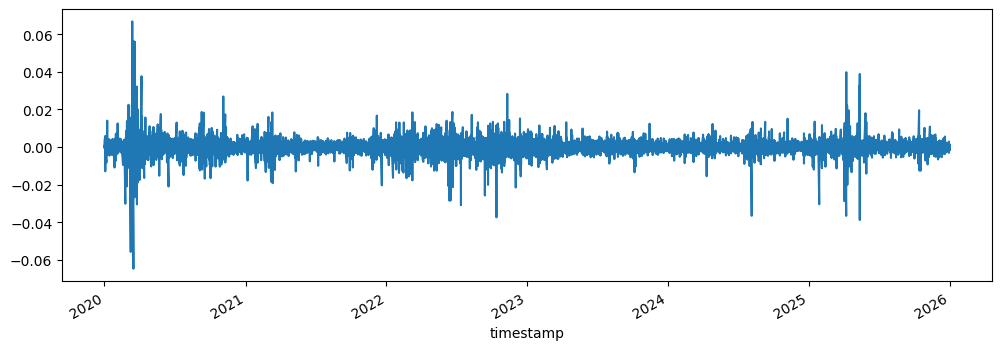

In [17]:
df["log_return"].plot(figsize=(12,4))

### __Construccion de pipeline para N_BEATS__
El flujo será:
- calcular retornos

- calcular volatilidad

- normalizar retornos

- construir ventanas temporales

- construir targets a 2h

- convertir a tensores para PyTorch

#### __Calculo de volatility rolling__
Usaremos volatilidad histórica sobre una 1 hora

In [18]:
df["volatility"] = df["log_return"].rolling(12).std()

#### __Calculo de retornos normalizados con volatilidad__

In [19]:
df["normalized_return"] = df["log_return"] / df["volatility"]

In [20]:
df = df.dropna()

#### __Construcción ventanas temporales__

In [21]:
WINDOW = 120
HORIZON = 24

series = df["normalized_return"].values

X = []
y = []

for i in range(WINDOW, len(series) - HORIZON):
    
    past_window = series[i-WINDOW:i]
    
    future_return = series[i + HORIZON]
    
    X.append(past_window)
    y.append(future_return)

X = np.array(X)
y = np.array(y)

In [22]:
print(X.shape)
print(y.shape)

(282601, 120)
(282601,)


#### __Conversión de los datasets a formato de PyTorch__

In [23]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

#### __Dividir datasets en train/validation/test__

In [24]:
train_size = int(len(X_tensor) * 0.7)
val_size = int(len(X_tensor) * 0.15)

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size:train_size+val_size]
y_val = y_tensor[train_size:train_size+val_size]

X_test = X_tensor[train_size+val_size:]
y_test = y_tensor[train_size+val_size:]

### __Creación de Modelo N_BEATS__

In [25]:
# Importamos torch
import torch
import torch.nn as nn
import torch.optim as optim

#### __Creamos el bloque de N_BEATS__
Cada bloque hace:

- fully connected layers

- genera coeficientes

- produce backcast y forecast

In [26]:
class NBeatsBlock(nn.Module):
    
    def __init__(self, input_size, hidden_size, n_layers, dropout):
        super().__init__()
        
        layers = []
        
        for i in range(n_layers):
            layers.append(nn.Linear(input_size if i == 0 else hidden_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        
        self.fc = nn.Sequential(*layers)
        
        self.theta = nn.Linear(hidden_size, input_size + 1)
        
        self.input_size = input_size
        
    def forward(self, x):
        
        h = self.fc(x)
        
        theta = self.theta(h)
        
        backcast = theta[:, :self.input_size]
        forecast = theta[:, -1]
        
        return backcast, forecast

#### __Creación modelo completo N_BEATS__
Aquí apilamos muchos bloques y aplicamos residual learning

In [27]:
class NBeatsModel(nn.Module):
    
    def __init__(self, input_size=120, hidden_size=256, n_layers=4, n_blocks=20, dropout=0.1):
        super().__init__()
        
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, hidden_size, n_layers, dropout)
            for _ in range(n_blocks)
        ])
    
    def forward(self, x):
        
        residual = x
        
        forecast = 0
        
        for block in self.blocks:
            
            backcast, block_forecast = block(residual)
            
            residual = residual - backcast
            
            forecast = forecast + block_forecast
        
        return forecast

#### __Inicializamos el modelo__

In [28]:
model = NBeatsModel(
    input_size=120,
    hidden_size=256,
    n_layers=4,
    n_blocks=20,
    dropout=0.1
)

#### __Añadimos el loss y el optimizer__

In [29]:
criterion = nn.HuberLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005
)

#### __Definimos training loop__

In [30]:
EPOCHS = 20
BATCH_SIZE = 256

dataset = torch.utils.data.TensorDataset(X_train, y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(EPOCHS):
    
    model.train()
    
    total_loss = 0
    
    for batch_x, batch_y in loader:
        
        optimizer.zero_grad()
        
        preds = model(batch_x)
        
        loss = criterion(preds, batch_y)
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {avg_loss:.6f}")

Epoch 1/20  Loss: 0.422396
Epoch 2/20  Loss: 0.419734
Epoch 3/20  Loss: 0.418452
Epoch 4/20  Loss: 0.414143
Epoch 5/20  Loss: 0.402605
Epoch 6/20  Loss: 0.375330
Epoch 7/20  Loss: 0.329462
Epoch 8/20  Loss: 0.276486
Epoch 9/20  Loss: 0.231426
Epoch 10/20  Loss: 0.199935
Epoch 11/20  Loss: 0.174515
Epoch 12/20  Loss: 0.157497
Epoch 13/20  Loss: 0.145526
Epoch 14/20  Loss: 0.135714
Epoch 15/20  Loss: 0.127283
Epoch 16/20  Loss: 0.120638
Epoch 17/20  Loss: 0.115374
Epoch 18/20  Loss: 0.110423
Epoch 19/20  Loss: 0.106637
Epoch 20/20  Loss: 0.102967


#### __Hacemos el validation__

In [31]:
model.eval()

with torch.no_grad():
    
    preds = model(X_val)
    
    val_loss = criterion(preds, y_val)
    
print("Validation Loss:", val_loss.item())

Validation Loss: 0.5116147398948669


### __Metricas útiles__

#### __Directional accuracy__
Mide cuantas veces los retornos han sido con la direccion correcta, aunque el número no haya sido el correcto

In [32]:
preds = model(X_test).detach().numpy()
real = y_test.numpy()

direction_pred = np.sign(preds)
direction_real = np.sign(real)

directional_accuracy = (direction_pred == direction_real).mean()

print("Directional accuracy:", directional_accuracy)

Directional accuracy: 0.48857068717416435


#### __Correlacion de retornos predicho y el real__

In [33]:
np.corrcoef(preds, real)[0,1]

np.float64(-0.0013052535514197652)